### Setup

In [1]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

/home/lumakyns/.local/share/mamba/envs/ML/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[device] {device}")

[device] cuda


### Sparse Autoencoder

In [3]:
class Autoencoder(nn.Module):
    def __init__(self, dim: tuple) -> None:
        super().__init__()
        
        input_dim, bottleneck_dim = dim
        
        self.encoder = nn.Linear(input_dim, bottleneck_dim)
        self.sigmoid = nn.Sigmoid()
        self.decoder = nn.Linear(bottleneck_dim, input_dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if x.ndim == 1:
            x = x.unsqueeze(0)
        z = self.encoder(x)
        z = self.sigmoid(z)
        z = self.decoder(z)
        return z

In [4]:
autoencoder = Autoencoder(dim=(100, 80)).to(device)
criterion   = nn.MSELoss()
optimizer   = torch.optim.Adam(autoencoder.parameters(), lr=1e-3)

In [5]:
batch_size = 128

mnist_mean = 0.1307
mnist_std = 0.3081
mnist_transform = transforms.Compose([
    transforms.Resize((10, 10)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[mnist_mean], std=[mnist_std]),
    transforms.Lambda(lambda x: x.view(-1)),
])

mnist_train = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=mnist_transform,
)

train_loader = DataLoader(mnist_train, batch_size=batch_size, shuffle=True)

### Training

In [ ]:
num_epochs = 10
epoch_losses = []

autoencoder.train()
epochbar = tqdm(range(1, num_epochs + 1), desc="Epochs")
for epoch in epochbar:
    # Find pHat
    # TODO: Collect pHat for the loss
    
    # Run Loss
    epoch_loss = 0.0
    for batch_inputs, _ in train_loader:
        batch_input = batch_inputs.to(device)
        optimizer.zero_grad()
        recon_input = autoencoder(batch_input)
        
        loss = criterion(recon_input, batch_input)
        loss.backward()
        optimizer.step()

        batch_loss = loss.item()
        epoch_loss += batch_loss * batch_inputs.size(0)
        epochbar.set_postfix({"loss": f"{batch_loss:.4f}"})

    epoch_loss /= len(train_loader.dataset)
    epoch_losses.append(epoch_loss)

Epochs: 100%|██████████| 10/10 [00:56<00:00,  5.61s/it, loss=0.0009]


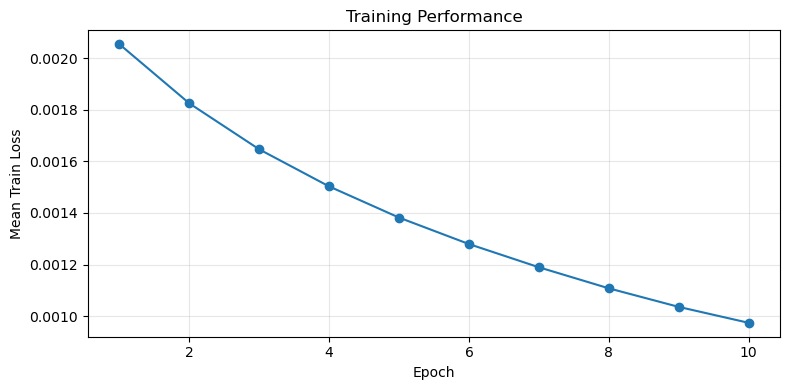

In [10]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, num_epochs + 1), epoch_losses, "o-")
plt.xlabel("Epoch")
plt.ylabel("Mean Train Loss")
plt.title("Training Performance")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Visualization

In [11]:
# TODO: Add visualization code